In [29]:
!wget -q https://github.com/chuanqi305/MobileNet-SSD/raw/refs/heads/master/deploy.prototxt
!wget -q https://github.com/chuanqi305/MobileNet-SSD/raw/refs/heads/master/mobilenet_iter_73000.caffemodel
!wget -q https://cdn.britannica.com/33/136133-050-9100988A/golden-retriever.jpg -O dog.jpg

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [31]:
# Load the model
net = cv2.dnn.readNetFromCaffe("deploy.prototxt",
                               "mobilenet_iter_73000.caffemodel")

# Class labels MobileNet-SSD was trained on
CLASSES = ["background", "aeroplane", "bicycle", "bird", "boat",
           "bottle", "bus", "car", "cat", "chair", "cow", "diningtable",
           "dog", "horse", "motorbike", "person", "pottedplant",
           "sheep", "sofa", "train", "tvmonitor"]

In [33]:
# Load and preprocess the input image
image = cv2.imread('dog.jpg')
(h, w) = image.shape[:2]

# Create blob from image
blob = cv2.dnn.blobFromImage(
    cv2.resize(image, (300, 300)),
    scalefactor=0.007843,
    size=(300, 300),
    mean=127.5
)

In [34]:
# Blob input to the network
net.setInput(blob)
detections = net.forward()

# Minimum confidence threshold
min_confidence = 0.5

In [35]:
# Process detections
for i in range(detections.shape[2]):

    # Step 4: Extract confidence
    confidence = detections[0, 0, i, 2]

    # Step 5: Filter weak detections
    if confidence > min_confidence:

        idx = int(detections[0, 0, i, 1])

        # Step 6: Compute bounding box coordinates
        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        (startX, startY, endX, endY) = box.astype("int")

        # Step 7: Draw bounding box and label
        label = f"{CLASSES[idx]}: {confidence:.2f}"
        cv2.rectangle(image, (startX, startY), (endX, endY),
                      (0, 255, 0), 2)

        y = startY - 15 if startY - 15 > 15 else startY + 15
        cv2.putText(image, label, (startX, y),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (0, 255, 0), 2)

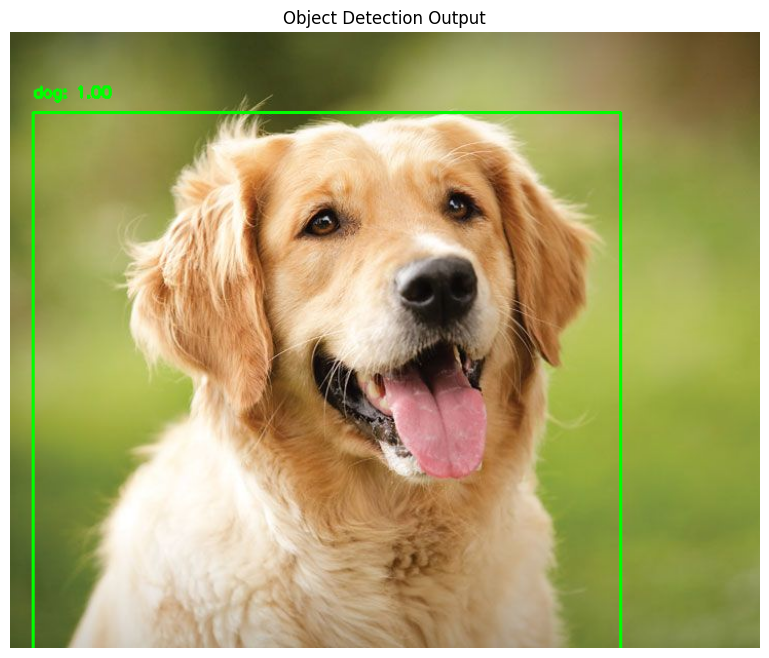

In [36]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Object Detection Output")
plt.show()